# Ostoskärrydatan tutkimus (03)

## Tietovaraston lataus

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Asetetaan visuaalinen tyyli
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Tarkistetaan datakansiot
raw_data_path = Path('data/raw')
processed_data_path = Path('data/processed')

print(f"Raw data path: {raw_data_path}")
print(f"Processed data path: {processed_data_path}")
print(f"\nRaw files: {list(raw_data_path.glob('*')) if raw_data_path.exists() else 'Path does not exist'}")

Raw data path: data/raw
Processed data path: data/processed

Raw files: [PosixPath('data/raw/node_53936.csv'), PosixPath('data/raw/node_53795.csv'), PosixPath('data/raw/node_53000.csv'), PosixPath('data/raw/node_51968.csv'), PosixPath('data/raw/node_51992.csv'), PosixPath('data/raw/node_53924.csv'), PosixPath('data/raw/node_64458.csv'), PosixPath('data/raw/node_51866.csv'), PosixPath('data/raw/node_54016.csv'), PosixPath('data/raw/node_52535.csv'), PosixPath('data/raw/node_52008.csv'), PosixPath('data/raw/node_51751.csv'), PosixPath('data/raw/node_42787.csv'), PosixPath('data/raw/node_53888.csv'), PosixPath('data/raw/node_53130.csv'), PosixPath('data/raw/node_45300.csv'), PosixPath('data/raw/node_51719.csv'), PosixPath('data/raw/node_51976.csv'), PosixPath('data/raw/node_53027.csv'), PosixPath('data/raw/node_3240.csv'), PosixPath('data/raw/node_52003.csv'), PosixPath('data/raw/node_51850.csv'), PosixPath('data/raw/node_52023.csv'), PosixPath('data/raw/node_53768.csv'), PosixPath('data/

## Datan lataus

In [3]:
# Ladataan raakadata CSV-tiedostoista
# Muuta tiedostonimi vastaamaan käytettävää tiedostoa
raw_file = 'data/raw/node_3200.csv'  # Voit muuttaa tätä

try:
    df = pd.read_csv(raw_file)
    print(f"Data ladattu onnistuneesti: {raw_file}")
    print(f"\nDatan koko: {df.shape}")
    print(f"\nSarakkeet: {list(df.columns)}")
except FileNotFoundError:
    print(f"Virhe: Tiedostoa {raw_file} ei löydy.")
    print("Varmista, että data on ladattu data/raw/ -kansioon.")

Data ladattu onnistuneesti: data/raw/node_3200.csv

Datan koko: (6489294, 6)

Sarakkeet: ['node_id', 'timestamp', 'x', 'y', 'z', 'q']


## Datan perustietojen tarkastelu

In [4]:
# Ensimäinen tarkastelu
print("=== DATAN PERUSTIEDOT ===")
print(f"\nDatan koko: {df.shape[0]} riviä, {df.shape[1]} saraketta")

print("\n=== SARAKKEET JA TYYPIT ===")
print(df.dtypes)

print("\n=== PUUTTUVAT ARVOT ===")
print(df.isnull().sum())

print("\n=== PERUSTILASTOT ===")
print(df.describe())

=== DATAN PERUSTIEDOT ===

Datan koko: 6489294 riviä, 6 saraketta

=== SARAKKEET JA TYYPIT ===
node_id      int64
timestamp      str
x            int64
y            int64
z            int64
q            int64
dtype: object

=== PUUTTUVAT ARVOT ===
node_id      0
timestamp    0
x            0
y            0
z            0
q            0
dtype: int64

=== PERUSTILASTOT ===
         node_id             x             y          z             q
count  6489294.0  6.489294e+06  6.489294e+06  6489294.0  6.489294e+06
mean      3200.0  7.801438e+02  2.594087e+03        0.0  6.484833e+01
std          0.0  1.977287e+03  7.415937e+02        0.0  3.327497e+01
min       3200.0 -3.281800e+04 -3.270500e+04        0.0  0.000000e+00
25%       3200.0  4.600000e+01  2.453000e+03        0.0  4.800000e+01
50%       3200.0  1.320000e+02  2.536000e+03        0.0  5.600000e+01
75%       3200.0  3.130000e+02  2.642000e+03        0.0  6.900000e+01
max       3200.0  3.265500e+04  3.270600e+04        0.0  2.550000e

## Datan siivous

In [5]:
# Poistetaan rivit, joissa on puuttuvia arvoja kriittisissä sarakkeissa
critical_columns = ['cart_id', 'timestamp', 'latitude', 'longitude']
available_columns = [col for col in critical_columns if col in df.columns]

if available_columns:
    df_cleaned = df.dropna(subset=available_columns)
    print(f"Rivit poistettu puuttuvista arvoista: {len(df) - len(df_cleaned)}")
else:
    df_cleaned = df.copy()
    print("Huom: Kriittisiä sarakkeita ei löydy, ei suoritettu puuttuvien arvojen poistoa.")

# Valinnainen: Poistetaan sarakkeet, joissa on enemmän kuin 50% puuttuvia arvoja
threshold = 0.5 * len(df_cleaned)
cols_to_drop = df_cleaned.columns[df_cleaned.isnull().sum() > threshold].tolist()
if cols_to_drop:
    df_cleaned = df_cleaned.drop(columns=cols_to_drop)
    print(f"Sarakkeet poistettu: {cols_to_drop}")

Rivit poistettu puuttuvista arvoista: 0


## Poikkeama-analyysi

In [6]:
# Tarkistetaan koordinaattien mahdolliset poikkeamat
if 'latitude' in df_cleaned.columns and 'longitude' in df_cleaned.columns:
    print("=== KOORDINAATTIANALYYSI ===")
    
    # Oletetaan kaupan rajat (muuta nämä sopiviin koordinaatteihin)
    # min_lat, max_lat, min_lon, max_lon = ...
    
    print(f"Latitude - min: {df_cleaned['latitude'].min()}, max: {df_cleaned['latitude'].max()}")
    print(f"Longitude - min: {df_cleaned['longitude'].min()}, max: {df_cleaned['longitude'].max()}")
    
    # Etsitään ääripäät (outliers)
    lat_outliers = df_cleaned[(df_cleaned['latitude'] < -90) | (df_cleaned['latitude'] > 90)]
    lon_outliers = df_cleaned[(df_cleaned['longitude'] < -180) | (df_cleaned['longitude'] > 180)]
    
    if not lat_outliers.empty:
        print(f"\nHuom: {len(lat_outliers)} riviä on ulkona laajuusasteelta (-90, 90)")
    if not lon_outliers.empty:
        print(f"Huom: {len(lon_outliers)} riviä on ulkona laajuusasteelta (-180, 180)")

## Datan visualisointi

=== SAAVUUSKARTTA ===
Numerisia sarakkeita: ['node_id', 'x', 'y', 'z', 'q']


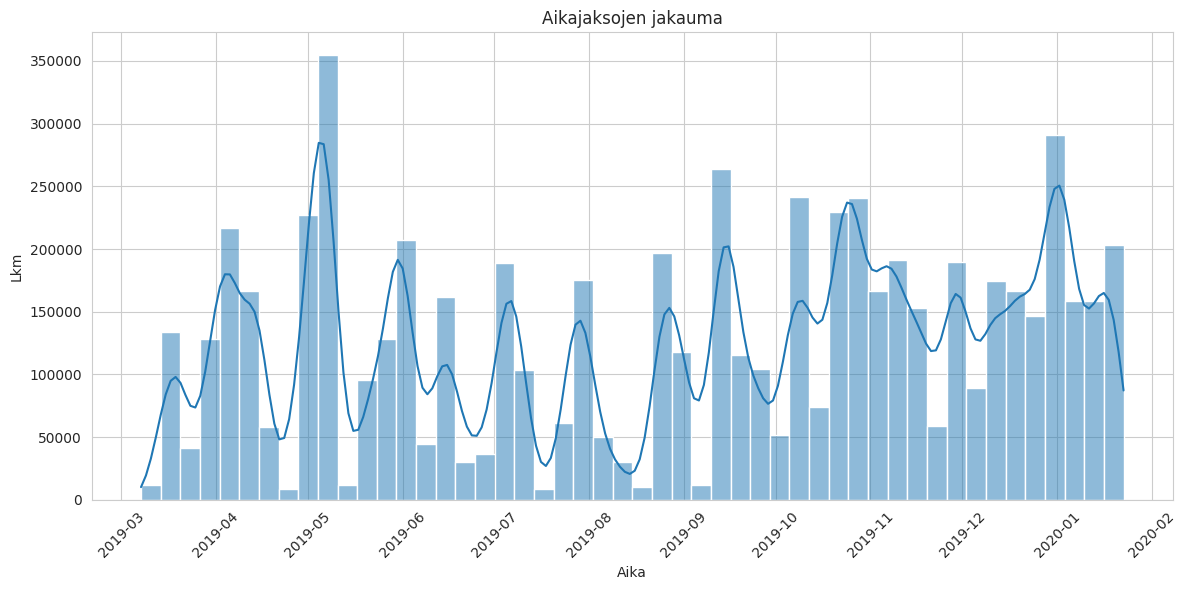

In [7]:
# Tarkistetaan saatavilla olevat sarakkeet visualisointia varten
print("=== SAAVUUSKARTTA ===")
available_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerisia sarakkeita: {available_cols}")

# Esimerkki visualisoinnista
if 'timestamp' in df_cleaned.columns:
    df_cleaned['timestamp'] = pd.to_datetime(df_cleaned['timestamp'])
    
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df_cleaned, x='timestamp', bins=50, kde=True)
    plt.title('Aikajaksojen jakauma')
    plt.xlabel('Aika')
    plt.ylabel('Lkm')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Datan tallennus

In [8]:
# Tallennetaan siivottu data processed-kansioon
processed_data_path.mkdir(parents=True, exist_ok=True)

output_file = processed_data_path / '01_03_cleaned_data.csv'
df_cleaned.to_csv(output_file, index=False)

print(f"\n=== DATAN TALLENNUS ===")
print(f"Siivottu data tallennettu: {output_file}")
print(f"Sarakkeita: {len(df_cleaned.columns)}")
print(f"Rivejä: {len(df_cleaned)}")


=== DATAN TALLENNUS ===
Siivottu data tallennettu: data/processed/01_03_cleaned_data.csv
Sarakkeita: 6
Rivejä: 6489294


## Seuraavat vaiheet

1. Käytä `df_cleaned` muuttujaa seuraavissa analyysissä
2. Luo lisää visualisointeja ja analyysiä
3. Vieraile `data/processed/` -kansiossa siivottujen tiedostojen luona